## Problema - Organización y búsqueda de productos en una tienda

**Instrucción:** completa esta plantilla con tu diseño y desarrollo. Evita incluir soluciones generadas automáticamente.



In [10]:
# @title Ingrese datos
nombre_estudiante = "Gabriel Andres Camargo Baron" 
carnet = 1000114473


## 1) Descripción del problema **[1 pts]**


In [11]:
#Plataforma Digital - Crecimiento de Suscriptores:
desc1= "Una plataforma de streaming analiza el crecimiento de nuevos suscriptores mes a mes. En el mes 0 ingresan 0 nuevos usuarios; en el mes 1 ingresa 1 nuevo usuario. A partir del mes 2, la cantidad de nuevos usuarios es la suma de los dos meses anteriores debido al impacto combinado de referidos y recomendaciones acumuladas"
t= "t(0)=0, t(1)=1, T(n)=T(n-1)+T(n-2) para n >2"
desc2="Se requiere determinar el número de nuevos suscriptores en el mes n optimizando el cálculo mediante programación dinámica con memoización (top-down)"


## 2) Requerimientos **[2 pts]**

Lista requerimientos **funcionales** y **no funcionales**.

requerimientos_funcionales=
RF1: El sistema debe recibir un entero no negativo n que representa el número del mes.
RF2: El sistema debe retornar el número de nuevos suscriptores para el mes n según la secuencia definida.
RF3: El sistema debe almacenar en memoria (diccionario/arreglo) los resultados intermedios para evitar recalcular subproblemas ya resueltos."
requerimientos_no_funcionales=
RNF1: Eficiencia temporal: La complejidad del algoritmo debe reducirse de O(2^n) (recursivo simple) a O(n) usando memoización.
RNF2: Eficiencia espacial: El espacio adicional en memoria debe ser máximo O(n) para la pila de llamadas y la tabla de memoización.




## 3) Historias de usuario **[2 pts]**
Escribe 3–5 historias de usuario con el formato visto en clase:
Incluye criterios de aceptación.



Historia de Usuario 1: Proyección de Suscriptores
 * Como: Analista de datos de la plataforma.
 * Quiero: Calcular el número proyectado de nuevos suscriptores para un mes específico (n).
 * Para: Anticipar el crecimiento de usuarios y planificar la capacidad de la infraestructura.
Criterios de Aceptación:
 * El sistema debe solicitar un valor entero mayor o igual a 0.
 * Si se consulta n=0, el resultado debe ser 0. Si se consulta n=1, el resultado debe ser 1.
 * Para valores de n \ge 2, el resultado debe ser la suma de los dos meses anteriores (T(n) = T(n-1) + T(n-2)).

Historia de Usuario 2: Consulta Eficiente de Resultados (Caché)
 * Como: Usuario del sistema.
 * Quiero: Obtener los resultados de meses calculados previamente sin demoras.
 * Para: Consultar proyecciones altas rápidamente sin que la aplicación se congele.
Criterios de Aceptación:
 * El algoritmo debe revisar primero si el mes consultado ya se encuentra almacenado en el diccionario de memoria (memo).
 * Si el valor ya existe en caché, se debe retornar inmediatamente en tiempo O(1).
 * El cálculo total para un mes nuevo no debe superar una complejidad temporal de O(n).

Historia de Usuario 3: Validación de Entradas de Usuario
 * Como: Usuario final del aplicativo.
 * Quiero: Que el sistema valide los datos ingresados antes de procesarlos.
 * Para: Evitar errores inesperados o fallos en el programa si se ingresan datos incorrectos.
Criterios de Aceptación:
 * Si el usuario ingresa un número negativo (ej. -5), el sistema debe capturar el error y mostrar un aviso indicando que solo se permiten números n \ge 0.
 * Si el usuario ingresa texto o un valor no numérico, la aplicación debe notificar el error de tipo sin cerrar la ejecución repentinamente
 
Historia de Usuario 4: Ejecución de Pruebas Unitarias
 * Como: Docente / Revisor del código.
 * Quiero: Disponer de una batería de pruebas automáticas (asserts).
 * Para: Validar la corrección del algoritmo, los casos base y el manejo de excepciones de forma transparente.
Criterios de Aceptación:
 * El sistema debe incluir una función de pruebas que verifique los casos base (n=0, n=1).
 * Debe validar valores intermedios y de rendimiento con valores más altos (ej. n=35).
 * Debe confirmar que las excepciones ante datos no válidos se ejecuten adecuadamente.

## 4) Diagramas de flujo **[5 pts]**
Incluye el diagrama que muestre el proceso general
Adjunta imagen y descríbelo claramente.


![alt text](image.png)



Inicio e Inicialización: La función recibe el entero n (mes a consultar) y la estructura de almacenamiento memo. Si memo no ha sido definido, se crea un diccionario vacío {}.
Evaluación de Memoria : Antes de realizar cualquier cálculo, se evalúa la condición n in memo.
Rama SÍ: El resultado de n ya fue procesado en una llamada previa, por lo que se retorna directamente memo[n] con complejidad constante O(1).
Verificación de Casos Base: Si el valor no está registrado en la memoria, se evalúa si n == 0 o n == 1.
Rama SÍ: Se retorna directamente n (0 para el mes 0, y 1 para el mes 1).
Cálculo Recursivo y Almacenamiento: Si n \ge 2:
Se realizan dos llamadas recursivas para resolver los subproblemas inmediatamente anteriores: res = suscriptores(n - 1) + suscriptores(n - 2).
Se guarda el valor resultante en la memoria asignando memo[n] = res.
Retorno y Fin: Se retorna el valor res, garantizando que ningún subproblema se calcule más de una vez durante la ejecución.

### 5) Análisis de complejidad **[15 pts]**
Incluye:
- Justificación:
Si resolvemos este problema de forma recursiva normal, la función empieza a calcular los mismos meses una y otra vez. Por ejemplo, para calcular el mes 5 tiene que calcular el mes 4 y el 3, pero para el mes 4 vuelve a calcular el 3. Esto genera un árbol gigante de llamadas que hace que el programa se vuelva lentísimo con números grandes, teniendo una complejidad exponencial O(2^n).
Al usar programación dinámica con memoización, guardamos en un diccionario (memo) cada resultado que ya calculamos. Antes de hacer cualquier operación, la función revisa si el mes ya está guardado: si ya existe, lo devuelve de una sin volver a calcularlo. Como la consulta e inserción en un diccionario toma tiempo constante O(1), logramos que cada subproblema desde 0 hasta n se resuelva una sola vez, bajando drásticamente el tiempo de ejecución.

- Función T[n]
 * Cada valor nuevo solo se calcula una vez y toma tiempo constante O(1) guardarlo y sumarlo.
 * Como hay n valores por calcular desde el mes 0 hasta el mes n, la función realiza n pasos.
Por lo tanto, la complejidad del algoritmo es:
T(n)=0(n)

- Mejor y peor caso con gráfica
 * Mejor caso — O(1): Pasa cuando le pedimos un mes que ya habíamos calculado antes y está en el diccionario, o si pedimos los casos base (n=0 o n=1).
 * Peor caso — O(n): Pasa la primera vez que corremos la función para un valor n con el diccionario vacío, ya que le toca calcular los n meses uno por uno hasta llegar a la base.
 

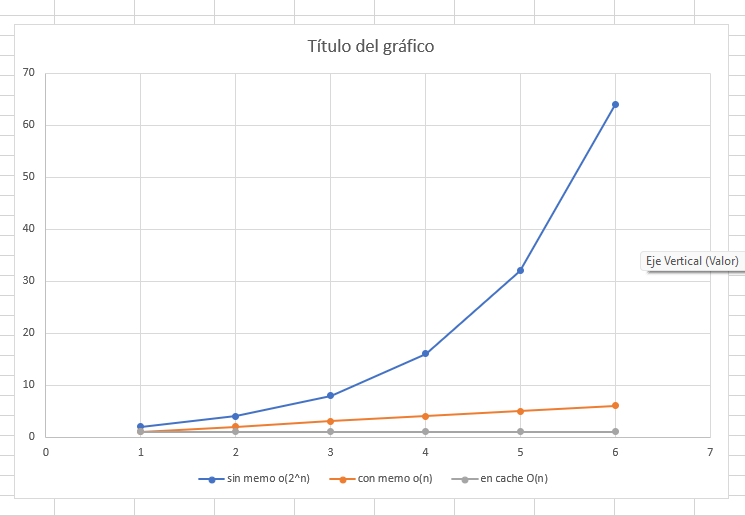

## 6) Código funcional **[15 pts]**
Incluye tu implementación completa.

No pegues código incompleto; debe ser ejecutable.


In [ ]:

def suscriptores_memoizacion(n: int, memo: dict = None) -> int:
    """
    Calcula el número de nuevos suscriptores.
    """
    if not isinstance(n, int) or n < 0:
        raise ValueError("El parámetro 'n' debe ser un número entero mayor o igual a 0.")

    if memo is None:
        memo = {}

    if n in memo:
        return memo[n]

    if n == 0:
        return 0
    if n == 1:
        return 1

    memo[n] = suscriptores_memoizacion(n - 1, memo) + suscriptores_memoizacion(n - 2, memo)
    return memo[n]


def ejecutar_aplicativo():
    print("=" * 50)
    print("SISTEMA DE PROYECCIÓN DE SUSCRIPTORES")
    print("=" * 50)
    
    try:
        entrada = input("Ingrese el número del mes a consultar (n >= 0): ")
        mes = int(entrada)
        
        cache_estados = {}
        total = suscriptores_memoizacion(mes, cache_estados)
        
        print("\n--- RESULTADOS ---")
        print(f"Mes consultado: {mes}")
        print(f"Proyección de suscriptores: {total:,}")
        print(f"Estados guardados en memo: {len(cache_estados)}")
        print("------------------")
        
    except ValueError as err:
        print(f"\nError de entrada: Deber ingresar un número entero válido.")
    except Exception as e:
        print(f"\nError inesperado: {e}")


if __name__ == "__main__":
    ejecutar_aplicativo()

SISTEMA DE PROYECCIÓN DE SUSCRIPTORES

Error de entrada: Deber ingresar un número entero válido (n >= 0).


## 7) Tests aplicados **[15 pts]**


Para comprobar que el algoritmo funciona correctamente y que la memoización realmente optimiza el uso de memoria, se diseñaron pruebas enfocadas en cuatro aspectos clave:
 * Casos base (n=0 y n=1):
   Se probó que la función retorne directamente 0 y 1 sin hacer llamadas recursivas innecesarias, asegurando que el proceso se detenga correctamente en las condiciones iniciales.
 * Valores intermedios:
   Se evaluó el comportamiento con valores conocidos (como n=2, 3, 5 y 10) para confirmar que la suma de los subproblemas anteriores (T(n-1) + T(n-2)) entregue los resultados esperados según la fórmula del problema.
 * Verificación de la caché (diccionario memo):
   Se inspeccionó el estado del diccionario para confirmar que guarde exactamente los n+1 resultados calculados. Esto demuestra que no se repiten cálculos de subproblemas ya resueltos, manteniendo la complejidad temporal en O(n) y el consumo de espacio en O(n).
 * Manejo de errores:
   Se ingresaron valores no válidos (como números negativos) para verificar que la validación de la entrada capture el error (ValueError) y el programa no falle por un desbordamiento en la pila de llamadas (stack overflow).